# 05. Heat Demand & Heat Pumps

Every model so far has stayed within a single energy carrier: electricity. This model introduces the
first **sector coupling** — a second energy carrier, heat, connected to the electrical system through
a heat pump.

The objective is to extend the Model 04 system (10 MW Solar PV + 15 MW Wind + 4 MW/8 MWh Battery +
6 MW average industrial load + two-directional grid connection) with a **3 MW heat pump** serving a
fixed **district heating demand**. The heat pump draws from the same electricity bus as everything
else, so it competes for the same renewable generation as the industrial load and the battery.

## 🛠️ System Topology
1. **Buses:** `electricity_bus` (unchanged from Model 04) and a new `heat_bus`.
2. **Generators (Source):** Solar PV (10 MW) and Wind (15 MW), unchanged.
3. **Generators (Grid, two-directional):** `Grid_Import` and `Grid_Export`, unchanged.
4. **Loads:** The industrial electrical load from Model 04, plus a new seasonal (winter-high)
   `Heat_Demand` load on `heat_bus`.
5. **Storage:** The `Battery`, unchanged.
6. **Links (conversion):** `Heat_Pump` — a `Link` with `bus0="electricity_bus"` and
   `bus1="heat_bus"`, scaled by a fixed **Coefficient of Performance (COP)**. A COP of 3.5 means
   every 1 MWh of electricity in produces 3.5 MWh of heat out — this efficiency multiplier is what
   makes heat pumps such a cheap way to decarbonize heating compared to direct electric heating.

Because the heat pump draws from the same bus as the battery and the industrial load, it is subject
to exactly the same merit order as everything else: solar and wind (€0 marginal cost) are always
cheaper than `Grid_Import` (priced at the market rate), so the solver will run the heat pump on
renewable power whenever it's available, and fall back to grid electricity only when it must — the
same "renewables-first" behavior we've seen since Model 03, now extended to heating.

<img src="../assets/model_5.jpg" alt="Model 05 System Topology" width="800">


In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

# Import custom publication-quality plotting style
sys.path.append('../')
from utils.viz_utils import set_nature_style

# Activate global styling
set_nature_style()

# Load processed data
df_pv = pd.read_csv('../data/processed/pv_2025_hourly.csv', index_col='time', parse_dates=True)
df_wind = pd.read_csv('../data/processed/wind_2025_hourly.csv', index_col='time', parse_dates=True)
df_price = pd.read_csv('../data/processed/electricity_price_2025_hourly.csv', index_col='time', parse_dates=True)

# This completely eliminates any duplicate timestamps caused by Daylight Saving Time.
perfect_index = pd.date_range(start='2025-01-01 00:00', end='2025-12-31 23:00', freq='1h')

# Force all three dataframes to use this clean index
df_pv.index = perfect_index
df_wind.index = perfect_index
df_price.index = perfect_index

df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)


## ⚙️ Technical Parameters

The electricity-side parameters are carried over unchanged from Model 04. A new `heat_pump` entry
defines its electrical input rating and COP, and a new `heat_demand` entry defines the seasonal
demand shape — no district heating data file was supplied for this model, so (as in the industrial
load) the profile is generated directly in code.


In [2]:
# Centralized dictionary for technical and economic parameters
tech_param = {
    'solar_pv': {
        'p_nom': 10.0,          # Nominal capacity of the solar PV system in MW
        'marginal_cost': 0.0    # Marginal cost of solar PV generation in $/MWh
    },
    'wind': {
        'p_nom': 15.0,          # Nominal capacity of the wind plant in MW
        'marginal_cost': 0.0    # Marginal cost of wind generation in $/MWh
    },
    'market_grid': {
        'import_p_nom': 20.0,   # Maximum import capacity from the grid
        'export_p_nom': 18.0    # Maximum export capacity to the grid
    },
    'demand': {
        'day_load_mw': 8.0,     # Electrical load during working hours (08:00-18:00)
        'night_load_mw': 4.0    # Electrical load outside working hours
    },
    'battery': {
        'p_nom': 4.0,                # Charge/discharge power rating in MW
        'max_hours': 2.0,            # Duration -> 4 MW x 2h = 8 MWh usable capacity
        'efficiency_store': 0.95,    # Charging efficiency
        'efficiency_dispatch': 0.95  # Discharging efficiency (round-trip ~ 90%)
    },
    'heat_pump': {
        'p_nom': 3.0,            # Electrical input rating in MW
        'cop': 3.5,              # Coefficient of Performance (fixed)
        'marginal_cost': 0.5     # Small O&M cost per MWh of heat output
    },
    'heat_demand': {
        'avg_mw': 3.0,           # Average district heating demand
        'amplitude_mw': 2.0      # Seasonal swing around the average (winter-high)
    }
}


## 🏗️ Initializing the Network

This is the first model with more than one energy carrier, so we now need two buses: one for
electricity (as before) and a new one for heat. The heat pump, added later, is the only component
that touches both.


In [3]:
# Initialize a new PyPSA network
n = pypsa.Network()
n.set_snapshots(df_pv.index)

# Add both energy-carrier buses
n.add("Bus", "electricity_bus")
n.add("Bus", "heat_bus")


Index(['heat_bus'], dtype='object')

## ⚡ Adding Generators and the Grid Connection

Solar, Wind, `Grid_Import`, and `Grid_Export` are added exactly as in Model 04, all still attached to
`electricity_bus`.


In [4]:
# 1. Add the Solar PV generator
n.add("Generator",
      "Solar_PV",
      bus="electricity_bus",
      p_nom=tech_param['solar_pv']['p_nom'],
      p_max_pu=df_pv['capacity_factor'],
      marginal_cost=tech_param['solar_pv']['marginal_cost'])

# 2. Add the Wind generator
n.add("Generator",
      "Wind",
      bus="electricity_bus",
      p_nom=tech_param['wind']['p_nom'],
      p_max_pu=df_wind['capacity_factor'],
      marginal_cost=tech_param['wind']['marginal_cost'])

# 3. Add the Grid Import generator (covers any shortfall)
n.add("Generator",
      "Grid_Import",
      bus="electricity_bus",
      p_nom=tech_param['market_grid']['import_p_nom'],
      marginal_cost=df_price['price'])

# 4. Add the Grid Export Market Sink (sells any surplus)
n.add("Generator",
      "Grid_Export",
      bus="electricity_bus",
      p_nom=tech_param['market_grid']['export_p_nom'],
      p_min_pu=-1.0,
      p_max_pu=0.0,
      marginal_cost=df_price['price'])


Index(['Grid_Export'], dtype='object')

## 🎯 Adding the Electrical and Heat Demands

The industrial electrical load is unchanged from Models 03-04. The new `Heat_Demand` load attaches to
`heat_bus` instead, using a seasonal sine curve (winter-high, summer-low) since no DH demand data
file was provided.


In [5]:
# Electrical load: same day/night industrial shape as Models 03-04
is_daytime = (n.snapshots.hour >= 8) & (n.snapshots.hour < 18)
electrical_load = np.where(is_daytime, tech_param['demand']['day_load_mw'], tech_param['demand']['night_load_mw'])
electrical_load = pd.Series(electrical_load, index=n.snapshots)

n.add("Load", "Industrial_Load", bus="electricity_bus", p_set=electrical_load)

# Heat load: seasonal (winter-high) shape - no data file needed
day_of_year = n.snapshots.dayofyear
heat_load = tech_param['heat_demand']['avg_mw'] - tech_param['heat_demand']['amplitude_mw'] * np.sin(
    (day_of_year - 80) * 2 * np.pi / 365
)
heat_load = pd.Series(np.clip(heat_load, 0.2, None), index=n.snapshots)

n.add("Load", "Heat_Demand", bus="heat_bus", p_set=heat_load)

print(f"Average heat demand: {heat_load.mean():.2f} MW (min {heat_load.min():.2f}, max {heat_load.max():.2f})")


Average heat demand: 3.00 MW (min 1.00, max 5.00)


## 🔋 Adding the Battery

Unchanged from Model 04, still on `electricity_bus`.


In [6]:
n.add("StorageUnit",
      "Battery",
      bus="electricity_bus",
      p_nom=tech_param['battery']['p_nom'],
      max_hours=tech_param['battery']['max_hours'],
      efficiency_store=tech_param['battery']['efficiency_store'],
      efficiency_dispatch=tech_param['battery']['efficiency_dispatch'],
      cyclic_state_of_charge=True)


Index(['Battery'], dtype='object')

## 🔗 Adding the Heat Pump

The heat pump is the bridge between the two buses: a `Link` with `bus0="electricity_bus"` (input) and
`bus1="heat_bus"` (output). Its `efficiency` parameter is set to the COP, so `p_nom` is defined in
terms of *electrical* input, and the actual heat delivered is `p_nom x COP`.

Because it draws electricity from the same bus as the industrial load and the battery, the heat pump
automatically joins the same merit order — no extra constraint is needed to make it prefer
renewables, it simply falls out of solar and wind being the cheapest electrons on the bus.


In [7]:
n.add("Link",
      "Heat_Pump",
      bus0="electricity_bus",
      bus1="heat_bus",
      p_nom=tech_param['heat_pump']['p_nom'],
      efficiency=tech_param['heat_pump']['cop'],
      marginal_cost=tech_param['heat_pump']['marginal_cost'])


Index(['Heat_Pump'], dtype='object')

## 🧠 Running the Optimization

With two coupled buses, a temporal battery, and a heat pump link all defined, the solver optimizes
the entire year at once across both energy carriers simultaneously.


In [8]:
# Optimize the network dispatch using the HiGHS solver
status, condition = n.optimize(solver_name='highs')

print(f"Solver Status: {status}")
print(f"Total Objective Value (Net Cost, Import minus Export Revenue): €{n.objective:,.2f}")


Index(['Heat_Pump'], dtype='object', name='Link')
Index(['electricity_bus', 'heat_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 25.80it/s]
INFO:linopy.io: Writing time: 1.19s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 70080 primals, 166440 duals
Objective: -9.22e+05
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


Solver Status: ok
Total Objective Value (Net Cost, Import minus Export Revenue): €-921,998.35


## 📊 Analyzing the Results

To check the "renewables-first" hypothesis for heating, we split the heat pump's electricity input
into the share that came from `Grid_Import` versus the share that came from on-site solar and wind
(inferred as the remainder). Since PyPSA doesn't track which physical electron went where on a shared
bus, this split is estimated using each hour's share of grid electricity in total supply, applied to
the heat pump's consumption in that hour.


Total Renewable Production:      68,182.94 MWh
Grid Import:                     14,408.24 MWh
Grid Export:                     24,803.77 MWh
---------------------------------------------
Heat Pump Electricity Input:     7,508.57 MWh
Heat Delivered:                  26,280.00 MWh
  - Estimated from Renewables:   6,141.30 MWh (81.8%)
  - Estimated from Grid Import:  1,367.27 MWh (18.2%)


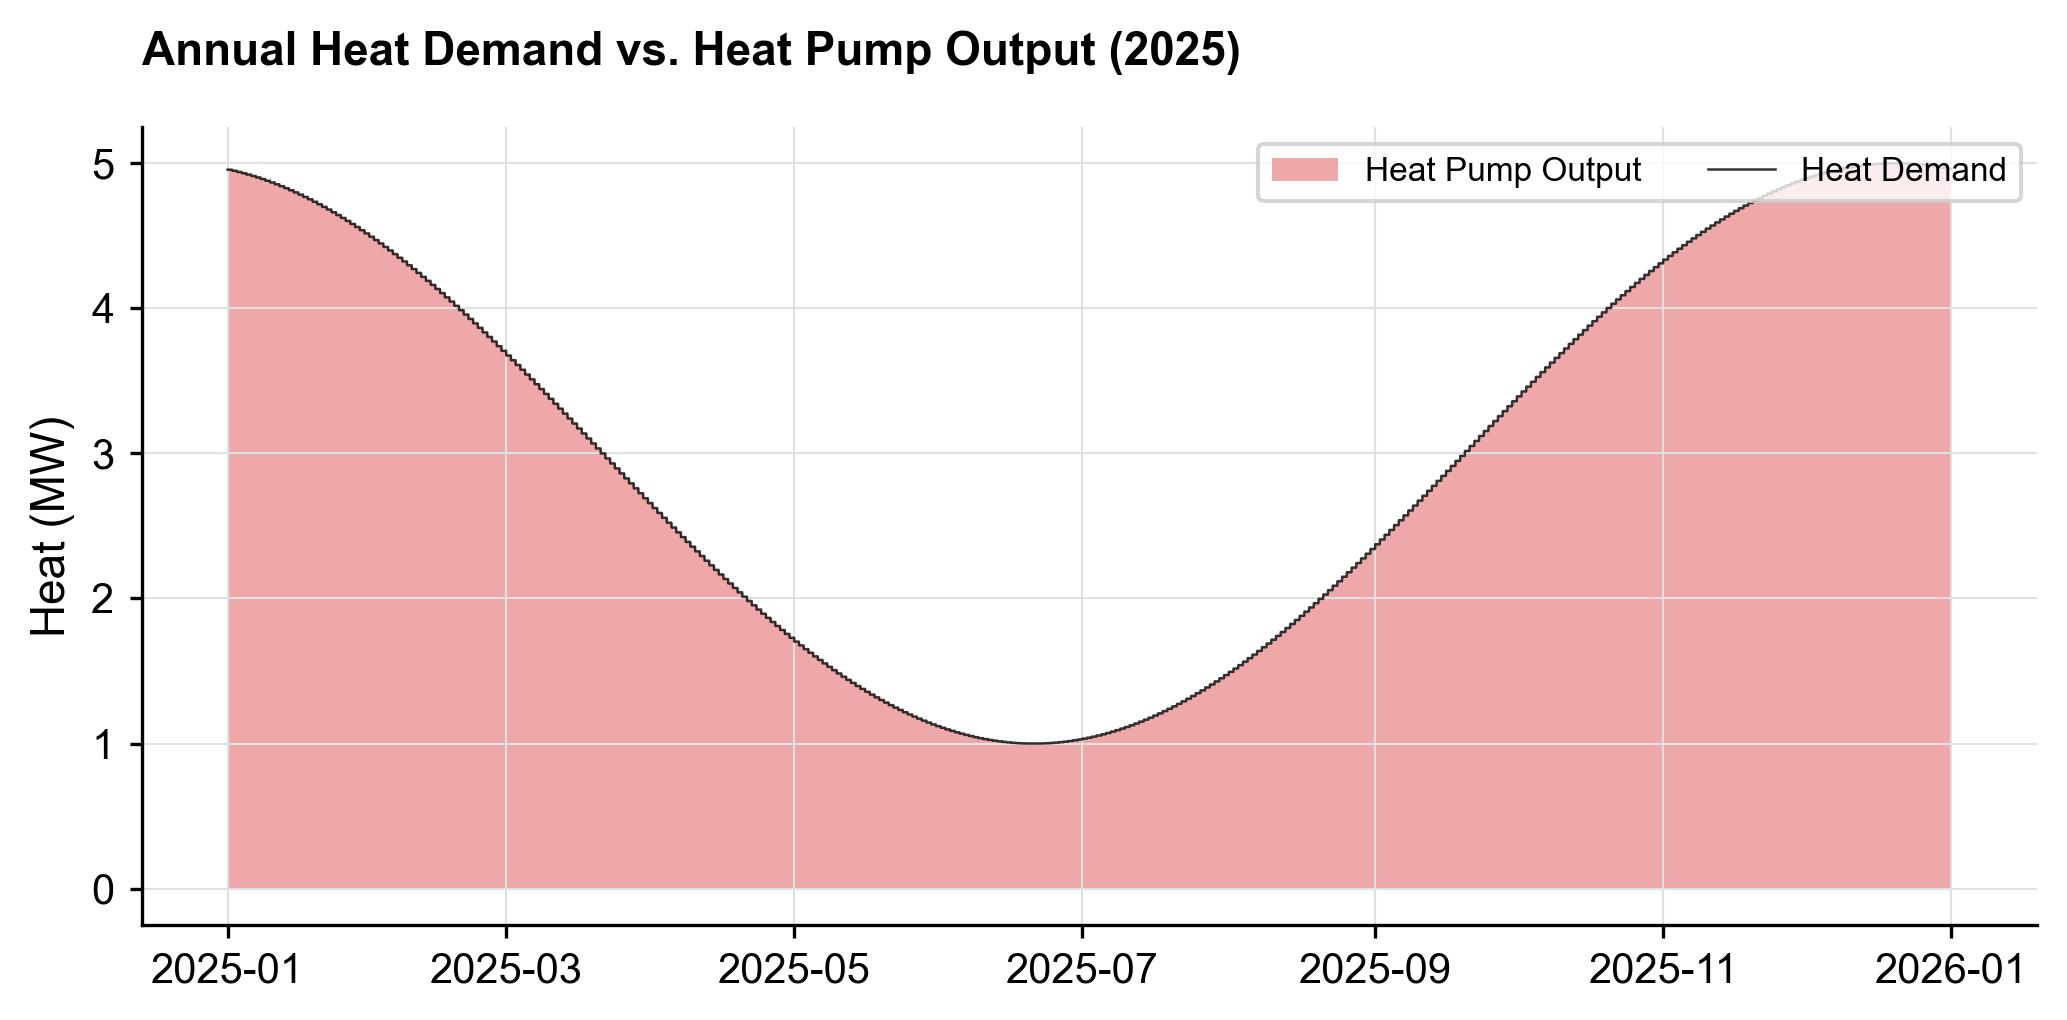

In [13]:
# Calculate Annual Totals
total_solar_mwh = n.generators_t.p['Solar_PV'].sum()
total_wind_mwh = n.generators_t.p['Wind'].sum()
total_import_mwh = n.generators_t.p['Grid_Import'].sum()
total_export_mwh = -n.generators_t.p['Grid_Export'].sum()

heat_pump_input_mwh = n.links_t.p0['Heat_Pump'].sum()
heat_pump_output_mwh = -n.links_t.p1['Heat_Pump'].sum()

# Estimate the renewable share of the heat pump's electricity input, hour by hour,
# using each hour's share of grid import in total electricity supply as a proxy.
total_supply = n.generators_t.p['Solar_PV'] + n.generators_t.p['Wind'] + n.generators_t.p['Grid_Import']
grid_share = (n.generators_t.p['Grid_Import'] / total_supply.replace(0, np.nan)).fillna(0)
heat_pump_from_grid_mwh = (n.links_t.p0['Heat_Pump'] * grid_share).sum()
heat_pump_from_re_mwh = heat_pump_input_mwh - heat_pump_from_grid_mwh

print(f"Total Renewable Production:      {total_solar_mwh + total_wind_mwh:,.2f} MWh")
print(f"Grid Import:                     {total_import_mwh:,.2f} MWh")
print(f"Grid Export:                     {total_export_mwh:,.2f} MWh")
print("-" * 45)
print(f"Heat Pump Electricity Input:     {heat_pump_input_mwh:,.2f} MWh")
print(f"Heat Delivered:                  {heat_pump_output_mwh:,.2f} MWh")
print(f"  - Estimated from Renewables:   {heat_pump_from_re_mwh:,.2f} MWh ({100*heat_pump_from_re_mwh/heat_pump_input_mwh:.1f}%)")
print(f"  - Estimated from Grid Import:  {heat_pump_from_grid_mwh:,.2f} MWh ({100*heat_pump_from_grid_mwh/heat_pump_input_mwh:.1f}%)")

# Plot heat demand vs. heat pump output over the full year
fig, ax = plt.subplots()

heat_pump_output = -n.links_t.p1['Heat_Pump']

ax.fill_between(n.snapshots, heat_pump_output, color='#d62728', alpha=0.4, linewidth=0, label='Heat Pump Output')
ax.plot(n.snapshots, heat_load, color='black', linewidth=0.6, alpha=0.8, label='Heat Demand')

ax.set_ylabel('Heat (MW)')
ax.set_title('Annual Heat Demand vs. Heat Pump Output (2025)', pad=15, loc='left', fontweight='bold')
ax.legend(loc='upper right', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()